In [108]:
import pandas as pd

In [109]:
train_df = pd.read_csv(r"C:\Users\ashis\Desktop\DEEP_LEARNING\Optmizer\House_price_prediction\train.csv")
test_df = pd.read_csv(r"C:\Users\ashis\Desktop\DEEP_LEARNING\Optmizer\House_price_prediction\test.csv")
test_ids = test_df["Id"]


In [110]:
print("train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train shape: (1460, 81)
Test shape: (1459, 80)


In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
train_df.drop("Utilities", axis=1, inplace=True)
test_df.drop("Utilities", axis=1, inplace=True)
train_df.drop("Condition2", axis=1, inplace=True)
test_df.drop("Condition2", axis=1, inplace=True)

In [113]:
# train_df["Condition1"].value_counts()
# train_df["Condition2"].value_counts()

In [114]:
train_df.groupby("BldgType")["SalePrice"].mean().sort_values()

BldgType
2fmCon    128432.258065
Duplex    133541.076923
Twnhs     135911.627907
TwnhsE    181959.342105
1Fam      185763.807377
Name: SalePrice, dtype: float64

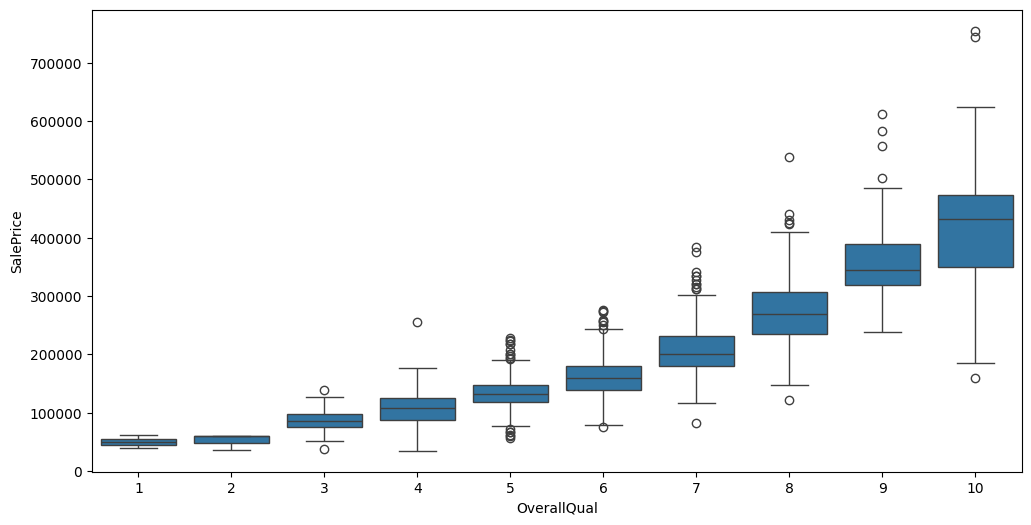

In [115]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=train_df,
    x="OverallQual",
    y="SalePrice"
)

plt.show()

In [116]:
# with open("/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt", "r") as f:
#     print(f.read())
    

## Data Understanding (EDA)

In [117]:
train_df.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,Inside,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,Corner,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,Corner,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [118]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [119]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [120]:
train_df.duplicated().sum()

np.int64(0)

In [121]:
train_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 79, dtype: int64

<Figure size 1000x1000 with 0 Axes>

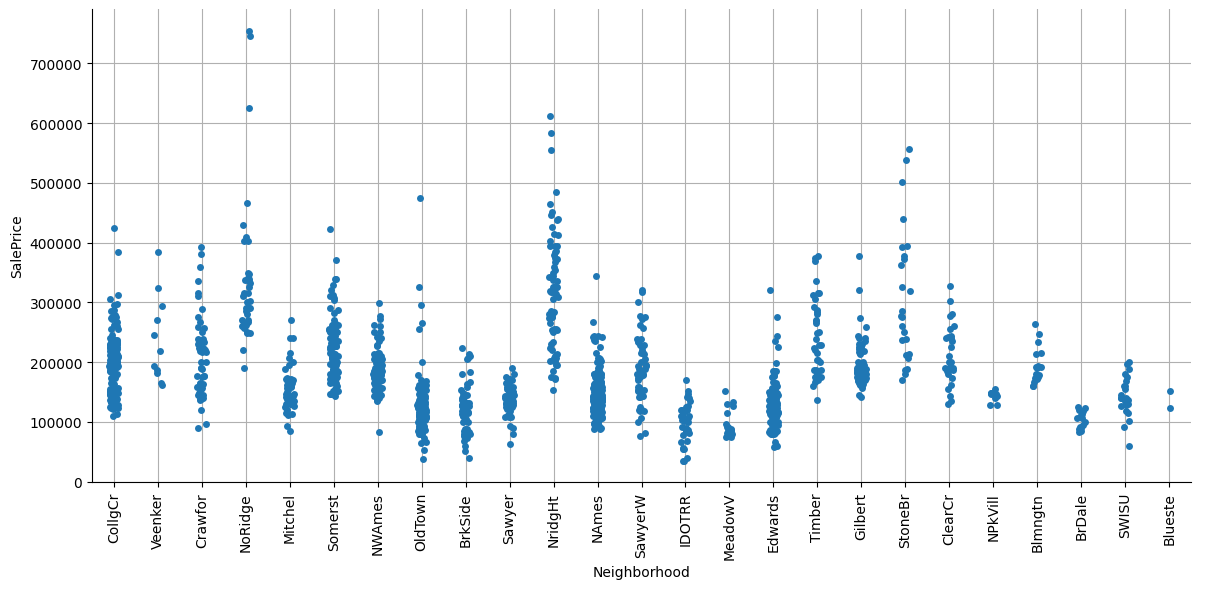

In [122]:
plt.figure(figsize = (10,10))
sns.catplot(
    data=train_df,
    x="Neighborhood",
    y="SalePrice",
    height=6,
    aspect=2,
    
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid()
plt.show()

In [123]:
def find_col_has_missing(data):
    missing_value_in_column = []

    for column in data.columns:
        if data[column].isnull().sum() > 0:
            missing_value_in_column.append(column)

    return missing_value_in_column

missing_cols = find_col_has_missing(train_df)
print(missing_cols)


['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


In [124]:
# test_df['Utilities'].value_counts()

check the distribution 

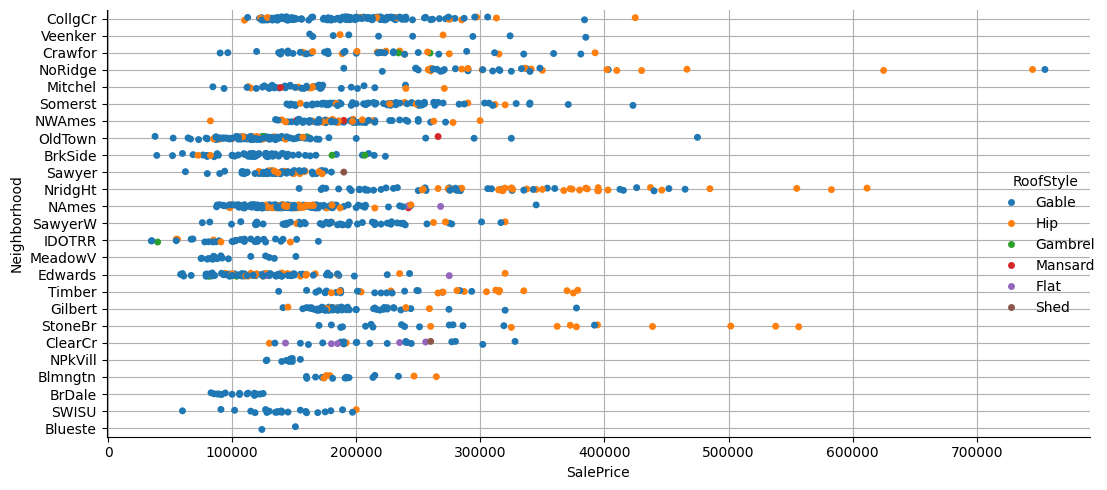

In [125]:
g = sns.catplot(
    data=train_df,
    y="Neighborhood",
    x="SalePrice",
    hue="RoofStyle",
    aspect=2,
    height=5
)

g.fig.tight_layout()
plt.grid()
plt.show()

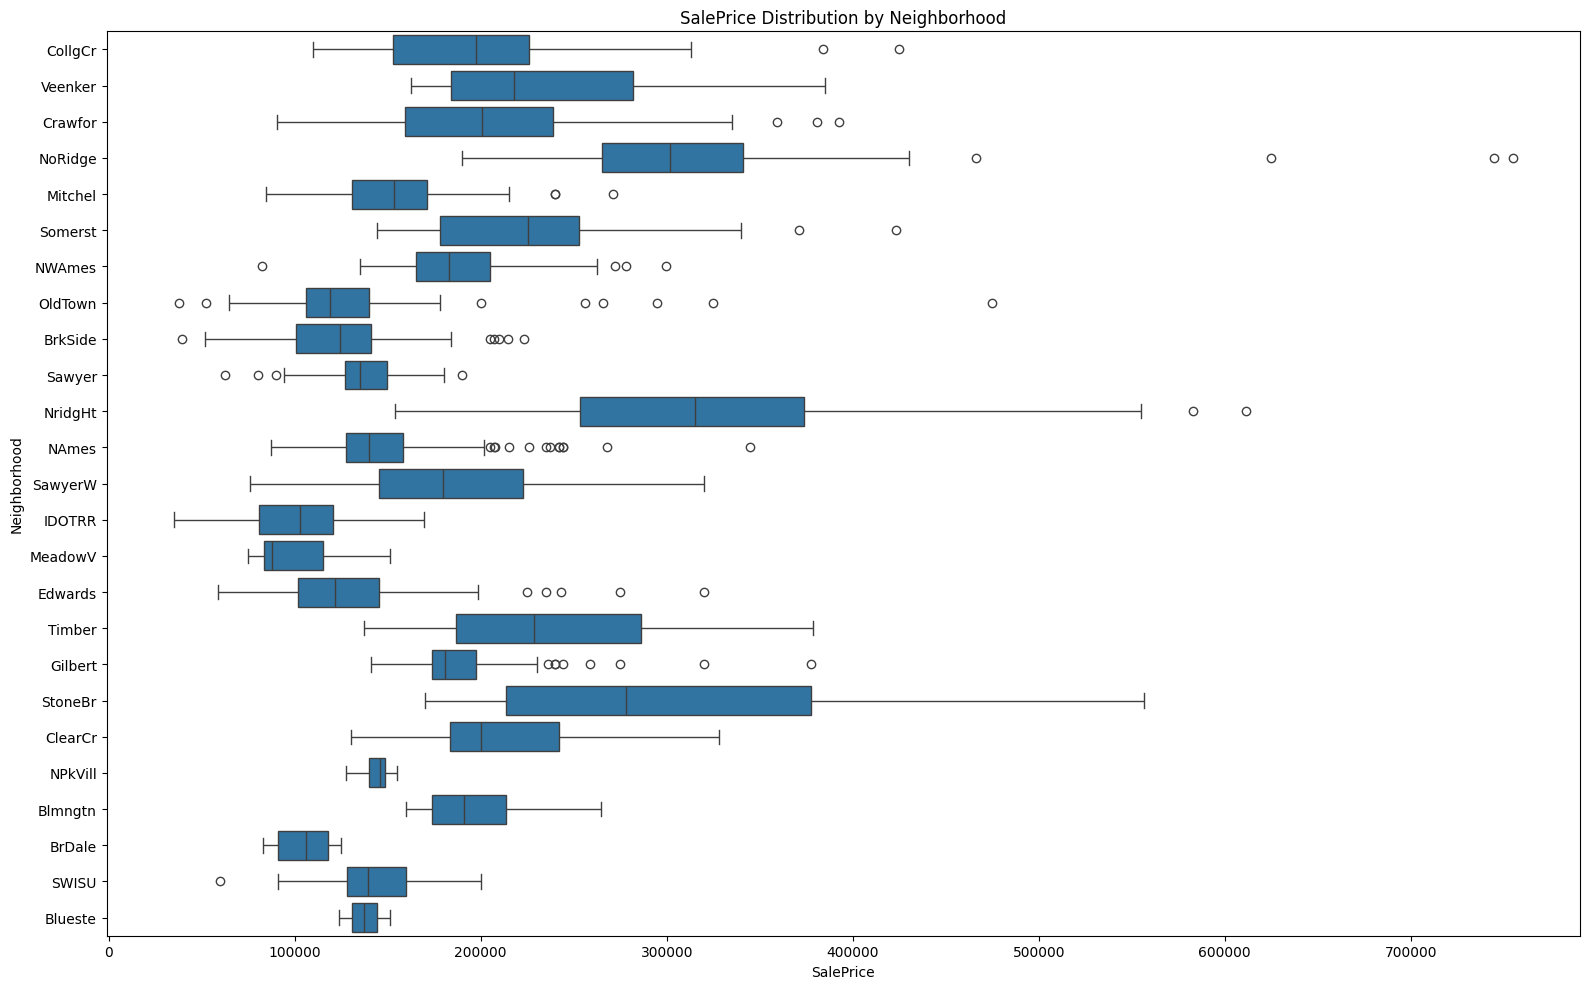

In [126]:
plt.figure(figsize=(16, 10))
sns.boxplot(y='Neighborhood', x='SalePrice', data=train_df, orient='h')
plt.title("SalePrice Distribution by Neighborhood")
plt.tight_layout()
plt.show()

In [127]:
train_df["Alley"].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

In [128]:
q1 = train_df['SalePrice'].quantile(0.25)
q3 = train_df['SalePrice'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
outliers = train_df[(train_df['SalePrice'] < lower_bound) | (train_df['SalePrice'] > upper_bound)] 


In [129]:
print(f"UpperBound: {upper_bound}")
print(f"LowerBound: {lower_bound}")
print(f"No. of Outliers: {len(outliers)}")
print(f"Outliers Enfluence as a wholesum: {(outliers['SalePrice'].sum())/train_df['SalePrice'].sum()}")
print(f"Outliers Enfluence as a amount in the dataset: {(len(outliers))/len(train_df)}")

UpperBound: 340037.5
LowerBound: 3937.5
No. of Outliers: 61
Outliers Enfluence as a wholesum: 0.09836722372874777
Outliers Enfluence as a amount in the dataset: 0.04178082191780822


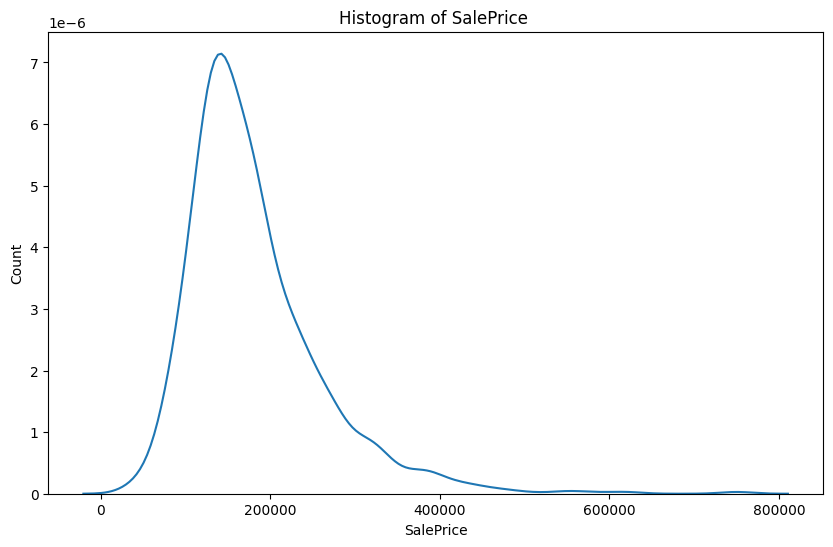

In [130]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train_df, x='SalePrice')
plt.title('Histogram of SalePrice ')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()

# this id right sqewed we will apply log transform to SalePrice


In [131]:
import numpy as np
train_df["SalePrice"] = train_df["SalePrice"].apply(np.log1p)

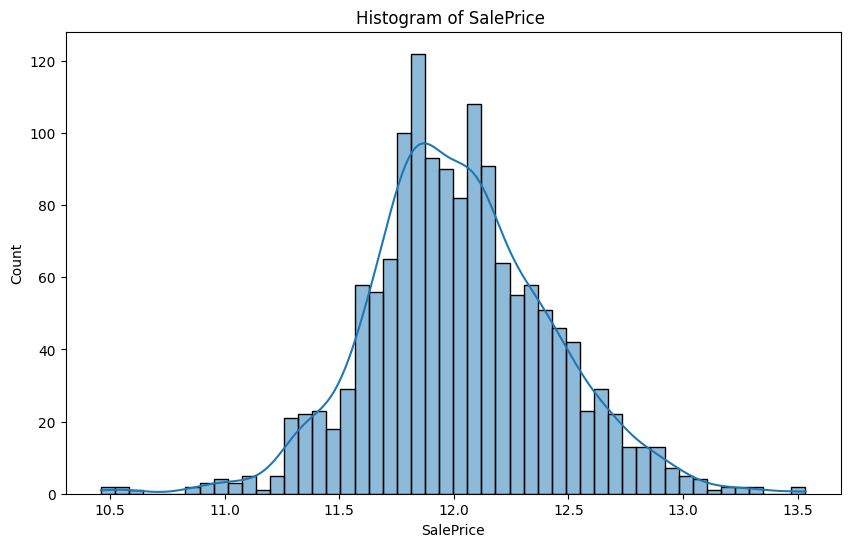

In [132]:
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='SalePrice', bins=50, kde=True)
plt.title('Histogram of SalePrice ')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()


# filling missing values 

# I fill all the missing values with the mode and medien on test and train data 

In [133]:
# Numerical columns
train_df["LotFrontage"] = train_df["LotFrontage"].fillna(train_df["LotFrontage"].median())
test_df["LotFrontage"] = test_df["LotFrontage"].fillna(test_df["LotFrontage"].median())

train_df["GarageYrBlt"] = train_df["GarageYrBlt"].fillna(train_df["GarageYrBlt"].median())
test_df["GarageYrBlt"] = test_df["GarageYrBlt"].fillna(test_df["GarageYrBlt"].median())

# Fill with "None"
train_df["PoolQC"] = train_df["PoolQC"].fillna("None")
test_df["PoolQC"] = test_df["PoolQC"].fillna("None")

train_df["Fence"] = train_df["Fence"].fillna("None")
test_df["Fence"] = test_df["Fence"].fillna("None")

train_df["Alley"] = train_df["Alley"].fillna("None")
test_df["Alley"] = test_df["Alley"].fillna("None")

train_df["FireplaceQu"] = train_df["FireplaceQu"].fillna("None")
test_df["FireplaceQu"] = test_df["FireplaceQu"].fillna("None")

train_df["MiscFeature"] = train_df["MiscFeature"].fillna("None")
test_df["MiscFeature"] = test_df["MiscFeature"].fillna("None")

# Fill with mode
train_df["Electrical"] = train_df["Electrical"].fillna(train_df["Electrical"].mode()[0])
test_df["Electrical"] = test_df["Electrical"].fillna(test_df["Electrical"].mode()[0])

train_df["KitchenQual"] = train_df["KitchenQual"].fillna(train_df["KitchenQual"].mode()[0])
test_df["KitchenQual"] = test_df["KitchenQual"].fillna(test_df["KitchenQual"].mode()[0])

train_df["SaleType"] = train_df["SaleType"].fillna(train_df["SaleType"].mode()[0])
test_df["SaleType"] = test_df["SaleType"].fillna(test_df["SaleType"].mode()[0])

train_df["Exterior1st"] = train_df["Exterior1st"].fillna(train_df["Exterior1st"].mode()[0])
test_df["Exterior1st"] = test_df["Exterior1st"].fillna(test_df["Exterior1st"].mode()[0])

train_df["Exterior2nd"] = train_df["Exterior2nd"].fillna(train_df["Exterior2nd"].mode()[0])
test_df["Exterior2nd"] = test_df["Exterior2nd"].fillna(test_df["Exterior2nd"].mode()[0])

In [134]:
# Masonry veneer
train_df["MasVnrType"] = train_df["MasVnrType"].fillna("None")
test_df["MasVnrType"] = test_df["MasVnrType"].fillna("None")

train_df["MasVnrArea"] = train_df["MasVnrArea"].fillna(0)
test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(0)

# Basement columns
train_df["BsmtQual"] = train_df["BsmtQual"].fillna("None")
test_df["BsmtQual"] = test_df["BsmtQual"].fillna("None")

train_df["BsmtCond"] = train_df["BsmtCond"].fillna("None")
test_df["BsmtCond"] = test_df["BsmtCond"].fillna("None")

train_df["BsmtExposure"] = train_df["BsmtExposure"].fillna("None")
test_df["BsmtExposure"] = test_df["BsmtExposure"].fillna("None")

train_df["BsmtFinType1"] = train_df["BsmtFinType1"].fillna("None")
test_df["BsmtFinType1"] = test_df["BsmtFinType1"].fillna("None")

train_df["BsmtFinType2"] = train_df["BsmtFinType2"].fillna("None")
test_df["BsmtFinType2"] = test_df["BsmtFinType2"].fillna("None")

# Garage columns
train_df["GarageType"] = train_df["GarageType"].fillna("None")
test_df["GarageType"] = test_df["GarageType"].fillna("None")

train_df["GarageFinish"] = train_df["GarageFinish"].fillna("None")
test_df["GarageFinish"] = test_df["GarageFinish"].fillna("None")

train_df["GarageQual"] = train_df["GarageQual"].fillna("None")
test_df["GarageQual"] = test_df["GarageQual"].fillna("None")

train_df["GarageCond"] = train_df["GarageCond"].fillna("None")
test_df["GarageCond"] = test_df["GarageCond"].fillna("None")

In [135]:
# train_df["LotFrontage"] = train_df["LotFrontage"].fillna(train_df["LotFrontage"].median())
# test_df["LotFrontage"] = test_df["LotFrontage"].fillna(test_df["LotFrontage"].median())

# train_df["Alley"] = train_df["Alley"].fillna("None")
# test_df["Alley"] = test_df["Alley"].fillna("None")

# train_df["MasVnrType"] = train_df["MasVnrType"].fillna(train_df["MasVnrType"].mode()[0])
# test_df["MasVnrType"] = test_df["MasVnrType"].fillna(test_df["MasVnrType"].mode()[0])

# train_df["BsmtQual"] = train_df["BsmtQual"].fillna(train_df["BsmtQual"].mode()[0])
# test_df["BsmtQual"] = test_df["BsmtQual"].fillna(test_df["BsmtQual"].mode()[0])

# train_df["BsmtCond"] = train_df["BsmtCond"].fillna(train_df["BsmtCond"].mode()[0])
# test_df["BsmtCond"] = test_df["BsmtCond"].fillna(test_df["BsmtCond"].mode()[0])

# train_df["BsmtExposure"] = train_df["BsmtExposure"].fillna(train_df["BsmtExposure"].mode()[0])
# test_df["BsmtExposure"] = test_df["BsmtExposure"].fillna(test_df["BsmtExposure"].mode()[0])

# train_df["BsmtFinType1"] = train_df["BsmtFinType1"].fillna(train_df["BsmtFinType1"].mode()[0])
# test_df["BsmtFinType1"] = test_df["BsmtFinType1"].fillna(test_df["BsmtFinType1"].mode()[0])

# train_df["BsmtFinType2"] = train_df["BsmtFinType2"].fillna(train_df["BsmtFinType2"].mode()[0])
# test_df["BsmtFinType2"] = test_df["BsmtFinType2"].fillna(test_df["BsmtFinType2"].mode()[0])

# train_df["FireplaceQu"] = train_df["FireplaceQu"].fillna(train_df["FireplaceQu"].mode()[0])
# test_df["FireplaceQu"] = test_df["FireplaceQu"].fillna(test_df["FireplaceQu"].mode()[0])

# train_df["GarageType"] = train_df["GarageType"].fillna(train_df["GarageType"].mode()[0])
# test_df["GarageType"] = test_df["GarageType"].fillna(test_df["GarageType"].mode()[0])

# train_df["GarageYrBlt"] = train_df["GarageYrBlt"].fillna(train_df["GarageYrBlt"].median())
# test_df["GarageYrBlt"] = test_df["GarageYrBlt"].fillna(test_df["GarageYrBlt"].median())

# train_df["GarageFinish"] = train_df["GarageFinish"].fillna(train_df["GarageFinish"].mode()[0])
# test_df["GarageFinish"] = test_df["GarageFinish"].fillna(test_df["GarageFinish"].mode()[0])

# train_df["GarageQual"] = train_df["GarageQual"].fillna(train_df["GarageQual"].mode()[0])
# test_df["GarageQual"] = test_df["GarageQual"].fillna(test_df["GarageQual"].mode()[0])

# train_df["GarageCond"] = train_df["GarageCond"].fillna(train_df["GarageCond"].mode()[0])
# test_df["GarageCond"] = test_df["GarageCond"].fillna(test_df["GarageCond"].mode()[0])

# train_df["PoolQC"] = train_df["PoolQC"].fillna(train_df["PoolQC"].mode()[0])
# test_df["PoolQC"] = test_df["PoolQC"].fillna(test_df["PoolQC"].mode()[0])

# train_df["Fence"] = train_df["Fence"].fillna(train_df["Fence"].mode()[0])
# test_df["Fence"] = test_df["Fence"].fillna(test_df["Fence"].mode()[0])

# train_df["MiscFeature"] = train_df["MiscFeature"].fillna(train_df["MiscFeature"].mode()[0])
# test_df["MiscFeature"] = test_df["MiscFeature"].fillna(test_df["MiscFeature"].mode()[0])

# train_df["LotFrontLotFrontageage"] = train_df["LotFrontLotFrontageage"].fillna(train_df["LotFrontLotFrontageage"].mode()[0])
# test_df["LotFrontLotFrontageage"] = test_df["LotFrontLotFrontageage"].fillna(test_df["LotFrontLotFrontageage"].mode()[0])

# train_df["Electrical"] = train_df["Electrical"].fillna(train_df["Electrical"].mode()[0])
# test_df["Electrical"] = test_df["Electrical"].fillna(test_df["Electrical"].mode()[0])

# train_df["MasVnrArea"] = train_df["MasVnrArea"].fillna(train_df["MasVnrArea"].mode()[0])
# test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(test_df["MasVnrArea"].mode()[0])

In [136]:
train_df.isnull().sum()[train_df.isnull().sum() > 0]

Series([], dtype: int64)

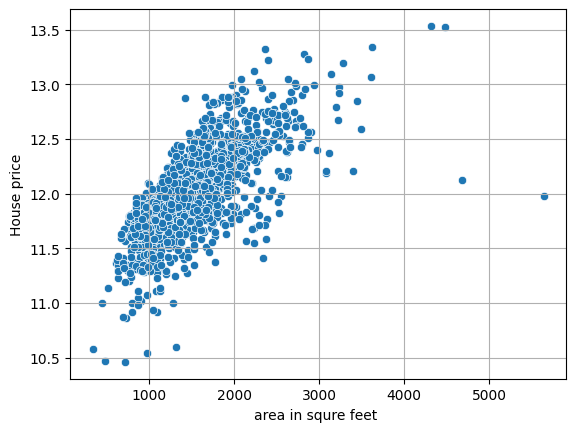

In [137]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train_df)
plt.xlabel('area in squre feet ')
plt.ylabel('House price')
plt.grid()
plt.show()

# for encoding perpose i use the pd.get_dummies fuction to encode the object in the dataset so the values are feed to the model without getting any error

# Feature ingineering 

In [138]:
# new column name remodeulation
train_df["RemodAge"] = train_df["YrSold"] - train_df["YearRemodAdd"]
test_df["RemodAge"] = test_df["YrSold"] - test_df["YearRemodAdd"]
# gRge age 

train_df["GarageAge"] = train_df["YrSold"] - train_df["GarageYrBlt"]
test_df["GarageAge"] = test_df["YrSold"] - test_df["GarageYrBlt"]

train_df["HouseAge"] = train_df["YrSold"] - train_df["YearBuilt"]
test_df["HouseAge"] = test_df["YrSold"] - test_df["YearBuilt"]

train_df["IsRemodeled"] = (
    train_df["YearBuilt"] != train_df["YearRemodAdd"]
).astype(int)

test_df["IsRemodeled"] = (
    test_df["YearBuilt"] != test_df["YearRemodAdd"]
).astype(int)

train_df["TotalBath"] = (
    train_df["FullBath"]
    + 0.5 * train_df["HalfBath"]
    + train_df["BsmtFullBath"]
    + 0.5 * train_df["BsmtHalfBath"]
)

test_df["TotalBath"] = (
    test_df["FullBath"]
    + 0.5 * test_df["HalfBath"]
    + test_df["BsmtFullBath"]
    + 0.5 * test_df["BsmtHalfBath"]
)

train_df["TotalSF"] = (
    train_df["TotalBsmtSF"]
    + train_df["1stFlrSF"]
    + train_df["2ndFlrSF"]
)

test_df["TotalSF"] = (
    test_df["TotalBsmtSF"]
    + test_df["1stFlrSF"]
    + test_df["2ndFlrSF"]
)

train_df["HasGarage"] = (train_df["GarageArea"] > 0).astype(int)
test_df["HasGarage"] = (test_df["GarageArea"] > 0).astype(int)

train_df["LargeGarage"] = (train_df["GarageArea"] > train_df["GarageArea"].median()).astype(int)
test_df["LargeGarage"] = (test_df["GarageArea"] > train_df["GarageArea"].median()).astype(int)

train_df["GarageScore"] = train_df["GarageArea"] * train_df["GarageCars"]
test_df["GarageScore"] = test_df["GarageArea"] * test_df["GarageCars"]





# Adding New features with help with Chat GPT 

In [139]:
train_df[["GarageArea", "SalePrice"]].corr()

,GarageArea,SalePrice
GarageArea,1.000000,0.650888
SalePrice,0.650888,1.000000


In [140]:
train_df = pd.get_dummies(train_df)
test_df = pd.get_dummies(test_df)

# Fix it with align 

In [141]:
y = train_df["SalePrice"]

X = train_df.drop(columns=["SalePrice"])

X = pd.get_dummies(X)
test_df = pd.get_dummies(test_df)

X, test_df = X.align(
    test_df,
    join="left",
    axis=1,
    fill_value=0
)

print(X.shape)
print(test_df.shape)

(1460, 302)
(1459, 302)


In [142]:
print(train_df.shape)
print(test_df.shape)


(1460, 303)
(1459, 302)


In [143]:
from scipy.stats import skew

numeric_feats = X.select_dtypes(include=np.number).columns

skewed_feats = X[numeric_feats].apply(
    lambda x: skew(x.dropna())
)

skewed_feats = skewed_feats[abs(skewed_feats) > 0.75]

for feat in skewed_feats.index:
    X[feat] = np.log1p(X[feat])
    test_df[feat] = np.log1p(test_df[feat])

In [144]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Using the model RandomForestRegressor 

In [145]:

# # Train model
# model = RandomForestRegressor(
#     n_estimators=500,
#     random_state=42
# )

# model.fit(X_train, y_train)

# # Predict validation set
# y_pred = model.predict(X_valid)

# # RMSE
# rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

# print("RMSE:", rmse)
# predictions = model.predict(test_df)
# predictions = np.expm1(predictions)

# submission = pd.DataFrame({
#     "Id": test_ids,
#     "SalePrice": predictions
# })

# submission.to_csv("submission.csv", index=False)

# making model Xgboost 


In [146]:
# import xgboost as xgb
# import pandas as pd
# import numpy as np

# # 1. Initialize the model with your absolute best parameters
# final_xgb_model = xgb.XGBRegressor(
#     learning_rate=0.01,
#     n_estimators=2200,
#     max_depth=4,
#     min_child_weight=2,
#     subsample=0.7,
#     colsample_bytree=0.7,
#     reg_lambda=1.5,
#     reg_alpha=0,
#     objective="reg:squarederror",
#     random_state=42,
#     device="cuda"  # Kept on GPU for lightning-fast training
# )

# # 2. Fit on the full training dataset
# final_xgb_model.fit(X_train, y_train)

# # 3. Generate predictions for the test set
# # Note: If your target variable (SalePrice) was log-transformed during preprocessing, 
# # you'll need to use np.expm1(preds) to convert it back to actual dollar amounts.
# test_preds = final_xgb_model.predict(X_valid)
# rmse = np.sqrt(mean_squared_error(y_valid, test_preds))

# print("RMSE:", rmse)
# print("Final model trained successfully! Ready for submission.")

In [147]:
# from xgboost import XGBRegressor

# # model1 = XGBRegressor(
# #     n_estimators=2200,
# #     max_depth=4,
# #     min_child_weight=2,
# #     subsample=0.7,
# #     colsample_bytree=0.7,
# #     reg_lambda=1.5,
# #     learning_rate=0.01,
# #     objective="reg:squarederror",
# #     random_state=42,
# #     n_jobs=-1
# # )

# model1 = XGBRegressor(
#     n_estimators=2531,
#     max_depth=3,
#     learning_rate=0.015137998558595536,
#     subsample=0.6106486839070331,
#     colsample_bytree=0.6693555984915334,
#     gamma=0.0038709311897990803,
#     min_child_weight=1,
#     reg_alpha=0.17964515790347424,
#     reg_lambda=0.0030733580818517684,
#     objective="reg:squarederror",
#     random_state=42,
#     seed = 42,
# )

# model1.fit(X_train, y_train)

# y_pred1 = model1.predict(X_valid)

# rmse = np.sqrt(mean_squared_error(y_valid, y_pred1))

# print("RMSE:", rmse)

# predictions1 = model1.predict(test_df)
# predictions1 = np.expm1(predictions1)

# submission1 = pd.DataFrame({
#     "Id": test_ids,
#     "SalePrice": predictions1
# })
# submission1.to_csv("submission3.csv", index=False)



# Use randomize search cv for the best prameters 


In [148]:
# from sklearn.model_selection import RandomizedSearchCV, KFold
# import xgboost as xgb

# # 1. Define the base model with GPU acceleration enabled
# xgb_model = xgb.XGBRegressor(
#     learning_rate=0.01,
#     objective="reg:squarederror",
#     random_state=42,
#     device="cuda"  # <--- This triggers GPU training (CUDA must be installed)
# )

# # 2. Define the hyperparameter search space
# param_distributions = {
#     'n_estimators': [2000, 3000, 4000],
#     'max_depth': [3, 4, 5, 6],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.7, 0.8, 0.9],
#     'colsample_bytree': [0.7, 0.8, 0.9],
#     'reg_alpha': [0, 0.01, 0.1, 1.0],
#     'reg_lambda': [0.5, 1.0, 2.0]
# }

# # 3. Setup Cross-Validation
# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# # 4. Setup Randomized Search
# # Note: n_jobs is removed here to prevent GPU memory crashes
# random_search = RandomizedSearchCV(
#     estimator=xgb_model,
#     param_distributions=param_distributions,
#     n_iter=20, 
#     scoring='neg_root_mean_squared_error',
#     cv=cv,
#     verbose=2,
#     random_state=42
# )

# # 5. Run the search (Replace X_train and y_train with your variables)
# # Note: It will automatically copy data to the GPU during fitting
# random_search.fit(X_train, y_train)

# # 6. Extract the best results
# print("Best Parameters found: ", random_search.best_params_)
# print("Best CV RMSE: ", -random_search.best_score_)

# # Your optimized model is ready to go
# best_model = random_search.best_estimator_

In [149]:
# # # Absolute Best Parameters:  {'colsample_bytree': 0.7, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 2200, 'reg_lambda': 1.5, 'subsample': 0.7}
# # # Absolute Best CV RMSE:  0.12072883163344753

# # Best Parameters found:  {'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 2000, 'min_child_weight': 1, 'max_depth': 4, 'colsample_bytree': 0.7}
# # Best CV RMSE:  0.12152964560603578

# from xgboost import XGBRegressor
# import pandas as pd
# import numpy as np

# # ----------------------------
# # Model 1 (your proven model)
# # ----------------------------
# model1 = XGBRegressor(
#     n_estimators=3000,
#     learning_rate=0.01,
#     max_depth=3,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective="reg:squarederror",
#     random_state=42
# )

# # ----------------------------
# # Model 2 (Optuna best model)
# # ----------------------------
# model2 = XGBRegressor(
#     n_estimators=2531,
#     max_depth=3,
#     learning_rate=0.015137998558595536,
#     subsample=0.6106486839070331,
#     colsample_bytree=0.6693555984915334,
#     gamma=0.0038709311897990803,
#     min_child_weight=1,
#     reg_alpha=0.17964515790347424,
#     reg_lambda=0.0030733580818517684,
#     objective="reg:squarederror",
#     random_state=42
# )

# # Train both models
# model1.fit(X, y)
# model2.fit(X, y)

# # Predict
# pred1 = model1.predict(test_df)
# pred2 = model2.predict(test_df)
# a
# # Ensemble (70% Model1 + 30% Model2)
# predictions = 0.7 * pred1 + 0.3 * pred2

# # If y was log-transformed using np.log1p()
# predictions = np.expm1(predictions)

# # Create submission
# submission = pd.DataFrame({
#     "Id": test_ids,
#     "SalePrice": predictions
# })

# # Save file
# submission.to_csv("submission_ensemble.csv", index=False)

# print(submission.head())
# print(submission.shape)
# print("Submission file saved as submission_ensemble.csv")



In [150]:
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# from xgboost import XGBRegressor
# import numpy as np

# # Split
# X_train, X_valid, y_train, y_valid = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42
# )

# # Model 1
# model1 = XGBRegressor(
#     n_estimators=3000,
#     learning_rate=0.01,
#     max_depth=3,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective="reg:squarederror",
#     random_state=42
# )

# # Model 2
# model2 = XGBRegressor(
#     n_estimators=2531,
#     max_depth=3,
#     learning_rate=0.015137998558595536,
#     subsample=0.6106486839070331,
#     colsample_bytree=0.6693555984915334,
#     gamma=0.0038709311897990803,
#     min_child_weight=1,
#     reg_alpha=0.17964515790347424,
#     reg_lambda=0.0030733580818517684,
#     objective="reg:squarederror",
#     random_state=42
# )

# Train
# model1.fit(X_train, y_train)
# model2.fit(X_train, y_train)

# # Predict validation set
# pred1 = model1.predict(X_valid)
# pred2 = model2.predict(X_valid)

# # Ensemble
# pred = 0.7 * pred1 + 0.3 * pred2

# # RMSE
# rmse = np.sqrt(mean_squared_error(y_valid, pred))

# print("RMSE:", rmse)

# LightGBM (Light Gradient Boosting Machine)

In [151]:
# import sys

# !{sys.executable} -m pip install lightgbm

In [152]:
# from lightgbm import LGBMRegressor

# model = LGBMRegressor(
#     n_estimators=3000,
#     learning_rate=0.005,
#     max_depth=4,
#     num_leaves=20,
#     min_child_samples=20,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.1,
#     reg_lambda=2,
#     random_state=42
# )

# model1.fit(X, y)

# predictions = model1.predict(test_df)

# # If SalePrice was log-transformed
# import numpy as np
# predictions = np.expm1(predictions)


# submission = pd.DataFrame({
#     "Id": test_ids,
#     "SalePrice": predictions
# })

# submission.to_csv("submission_lgbm.csv", index=False)

# print(submission.head())

# Voting regresser 


In [153]:
# from lightgbm import LGBMRegressor
# from xgboost import XGBRegressor
# from sklearn.ensemble import VotingRegressor

# from sklearn.metrics import mean_squared_error
# import pandas as pd
# import numpy as np



# # =========================
# # LightGBM
# # =========================
# lgb_model = LGBMRegressor(
#     n_estimators=3000,
#     learning_rate=0.005,
#     max_depth=4,
#     num_leaves=20,
#     min_child_samples=20,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.1,
#     reg_lambda=2,
#     random_state=42
# )

# # =========================
# # XGBoost
# # =========================
# xgb_model = XGBRegressor(
#     n_estimators=2531,
#     max_depth=3,
#     learning_rate=0.015137998558595536,
#     subsample=0.6106486839070331,
#     colsample_bytree=0.6693555984915334,
#     gamma=0.0038709311897990803,
#     min_child_weight=1,
#     reg_alpha=0.17964515790347424,
#     reg_lambda=0.0030733580818517684,
#     objective="reg:squarederror",
#     random_state=42
# )

# # =========================
# # Voting Regressor
# # =========================
# voting_model = VotingRegressor(
#     estimators=[
#         ("lgb", lgb_model),
#         ("xgb", xgb_model)
#     ]
# )

# # =========================
# # Train Validation Model
# # =========================
# voting_model.fit(X_train, y_train)

# # Validation Predictions
# valid_pred = voting_model.predict(X_valid)

# # RMSE
# rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
# print("Validation RMSE:", rmse)

# # =========================
# # Train on Full Dataset
# # =========================
# voting_model.fit(X, y)

# # Kaggle Predictions
# predictions = voting_model.predict(test_df)

# # If y = np.log1p(SalePrice)
# predictions = np.expm1(predictions)

# # =========================
# # Submission
# # =========================
# submission = pd.DataFrame({
#     "Id": test_ids,
#     "SalePrice": predictions
# })

# submission.to_csv("submission_voting.csv", index=False)

# print(submission.head())
# print("Submission Shape:", submission.shape)
# print("Saved: submission_voting.csv")

In [154]:
# import optuna
# import numpy as np

# from sklearn.model_selection import cross_val_predict
# from sklearn.metrics import mean_squared_error

# # Get OOF predictions
# lgb_oof = cross_val_predict(
#     lgb_model,
#     X,
#     y,
#     cv=5,
#     n_jobs=-1
# )

# xgb_oof = cross_val_predict(
#     xgb_model,
#     X,
#     y,
#     cv=5,
#     n_jobs=-1
# )

# def objective(trial):

#     weight = trial.suggest_float(
#         "lgb_weight",
#         0.0,
#         1.0
#     )

#     pred = (
#         weight * lgb_oof +
#         (1 - weight) * xgb_oof
#     )

#     rmse = np.sqrt(
#         mean_squared_error(y, pred)
#     )

#     return rmse

# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=100)

# print("Best Weight:", study.best_params)
# print("Best RMSE:", study.best_value)

# find my best resutl with this 1010 rank in kaggle 

In [ ]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

import pandas as pd
import numpy as np

# =====================================================
# Models
# =====================================================

lgb_model = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.005,
    max_depth=4,
    num_leaves=20,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=2531,
    max_depth=3,
    learning_rate=0.015137998558595536,
    subsample=0.6106486839070331,
    colsample_bytree=0.6693555984915334,
    gamma=0.0038709311897990803,
    min_child_weight=1,
    reg_alpha=0.17964515790347424,
    reg_lambda=0.0030733580818517684,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

cat_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.01,
    depth=4,
    loss_function='RMSE',
    verbose=0,
    random_seed=42
)

# =====================================================
# Stacking Model
# =====================================================

stack_model = StackingRegressor(
    estimators=[
        ('lgb', lgb_model),
        ('xgb', xgb_model),
        ('cat', cat_model)
    ],
    final_estimator=Ridge(alpha=10),
    cv=5,
    n_jobs=-1
)

# =====================================================
# Cross Validation
# =====================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_df))

for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    stack_model.fit(X_train, y_train)

    valid_pred = stack_model.predict(X_valid)

    oof_preds[valid_idx] = valid_pred

    fold_rmse = np.sqrt(
        mean_squared_error(y_valid, valid_pred)
    )

    print(f"Fold {fold} RMSE: {fold_rmse:.6f}")

    test_preds += (
        stack_model.predict(test_df)
        / kf.n_splits
    )

# =====================================================
# Overall CV Score
# =====================================================

cv_rmse = np.sqrt(
    mean_squared_error(y, oof_preds)
)

print("\nOverall CV RMSE:", cv_rmse)

# =====================================================
# Reverse log transform
# =====================================================

predictions = np.expm1(test_preds)

# =====================================================
# Submission
# =====================================================

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": predictions
})

submission.to_csv(
    "submission_stacking.csv",
    index=False
)

print("\nSubmission Preview:")
print(submission.head())

print("\nSubmission Shape:")
print(submission.shape)

print("\nSaved: submission_stacking.csv")